# 📘 บทที่ 14 — Hybrid ในตัว: LanceDB ทำ FTS + Vector เครื่องเดียว

บทที่ 7 เราเขียน BM25 เอง 20 บรรทัด + RRF เอง เพราะ Chroma ไม่มี FTS · **LanceDB มี native**
บทนี้: สร้าง FTS index + hybrid search ด้วย API ในตัว แล้วเทียบว่าได้ผลเหมือน BM25 มือ


In [1]:
import sys
IN_COLAB='google.colab' in sys.modules
if IN_COLAB:
    %pip -q install lancedb sentence-transformers tantivy
import lancedb, shutil
from lancedb.index import FTS
print('lancedb', lancedb.__version__, '· FTS engine: tantivy (Rust) ✓')


lancedb 0.34.0 · FTS engine: tantivy (Rust) ✓


In [2]:
# ---- embed อัจฉริยะ (Ollama ในเครื่อง / sentence-transformers บน Colab) ----
import urllib.request, json
import numpy as np
def _ok():
    try:
        urllib.request.urlopen('http://localhost:11434/api/tags', timeout=2); return True
    except Exception: return False
if _ok():
    def embed_texts(t):
        req=urllib.request.Request('http://localhost:11434/api/embed',data=json.dumps({'model':'bge-m3','input':list(t)}).encode(),headers={'Content-Type':'application/json'})
        with urllib.request.urlopen(req,timeout=180) as r: V=np.array(json.load(r)['embeddings'])
        return V/np.linalg.norm(V,axis=1,keepdims=True)
    print('embed: Ollama bge-m3 ✓')
else:
    from sentence_transformers import SentenceTransformer
    _m=SentenceTransformer('BAAI/bge-m3')
    def embed_texts(t): return _m.encode(list(t),normalize_embeddings=True)
    print('embed: sentence-transformers ✓')


embed: Ollama bge-m3 ✓


## 1) vault ที่มีรหัส/ชื่อเฉพาะปน (เหมือนบทที่ 7)


In [3]:
shutil.rmtree('./lance_hybrid', ignore_errors=True)
db = lancedb.connect('./lance_hybrid')
DOCS = [
    'สั่งบอร์ด ESP32 มา 5 ตัวสำหรับ workshop IoT เดือนหน้า',
    'PR #2740 แก้เรื่อง drift benchmark ของ vector search',
    'ไมโครคอนโทรลเลอร์ราคาถูกเหมาะสอนนักศึกษาเริ่มต้น',
    'สรุปวิธีตั้งค่า Arduino IDE ให้บอร์ดตระกูล espressif',
    'งานวิจัยเรื่องการวัดคุณภาพระบบค้นหาเชิงความหมาย',
]
V = embed_texts(DOCS)
tbl = db.create_table('docs', data=[{'id':str(i),'text':t,'vector':v.tolist()} for i,(t,v) in enumerate(zip(DOCS,V))])
print('docs:', tbl.count_rows())


docs: 5


## 2) ⭐ สร้าง FTS index — คำสั่งเดียว (แทน BM25 20 บรรทัดในบทที่ 7)


In [4]:
tbl.create_index('text', config=FTS(), replace=True)
print('FTS index สร้างแล้ว ✓ (tantivy BM25 engine)')

# ค้น keyword เป๊ะ — รหัส PR
r = tbl.search('2740', query_type='fts').limit(2).to_pandas()
print('\nFTS ค้น "2740":')
for _, row in r.iterrows(): print(f"   {row['text'][:50]}")


FTS index สร้างแล้ว ✓ (tantivy BM25 engine)

FTS ค้น "2740":
   PR #2740 แก้เรื่อง drift benchmark ของ vector sear


## 3) ⭐ Hybrid: vector + FTS ในคำสั่งเดียว (LanceDB รวม RRF ให้)


In [5]:
from lancedb.rerankers import RRFReranker
tbl.create_index(metric='cosine', vector_column_name='vector', replace=True) if False else None

def hybrid(q, k=3):
    qv = embed_texts([q])[0].tolist()
    return (tbl.search(query_type='hybrid')
            .vector(qv).text(q)
            .rerank(RRFReranker())
            .limit(k).to_pandas())

for q in ['PR #2740', 'บอร์ดสำหรับสอน IoT']:
    r = hybrid(q)
    print(f'Q: {q} → hybrid top-1: {r.iloc[0]["text"][:46]}')


Q: PR #2740 → hybrid top-1: PR #2740 แก้เรื่อง drift benchmark ของ vector 


Q: บอร์ดสำหรับสอน IoT → hybrid top-1: สั่งบอร์ด ESP32 มา 5 ตัวสำหรับ workshop IoT เด


## ✅ วัดผลตัวเอง #14


In [6]:
# FTS จับรหัสเป๊ะ
r = tbl.search('2740', query_type='fts').limit(1).to_pandas()
assert '2740' in r.iloc[0]['text'], 'FTS ต้องเจอ PR #2740'
# hybrid ชนะทั้งรหัส + ความหมาย
assert '2740' in hybrid('PR #2740').iloc[0]['text'], 'hybrid ต้องเจอรหัสเป๊ะ'
assert any(w in hybrid('บอร์ดสำหรับสอน IoT').iloc[0]['text'] for w in ['ESP32','ไมโคร']), 'hybrid ต้องเจอความหมาย'
print('✅ ผ่าน! LanceDB hybrid = FTS(tantivy) + vector + RRF ในตัว')
print('   → บทที่ 7 เราเขียน BM25+RRF เองเพื่อ*เข้าใจ* · production ใช้ engine ในตัว (เร็ว+scale)')


✅ ผ่าน! LanceDB hybrid = FTS(tantivy) + vector + RRF ในตัว
   → บทที่ 7 เราเขียน BM25+RRF เองเพื่อ*เข้าใจ* · production ใช้ engine ในตัว (เร็ว+scale)


## 📊 เห็นภาพ — LanceDB hybrid อันดับผล (Q: PR #2740)


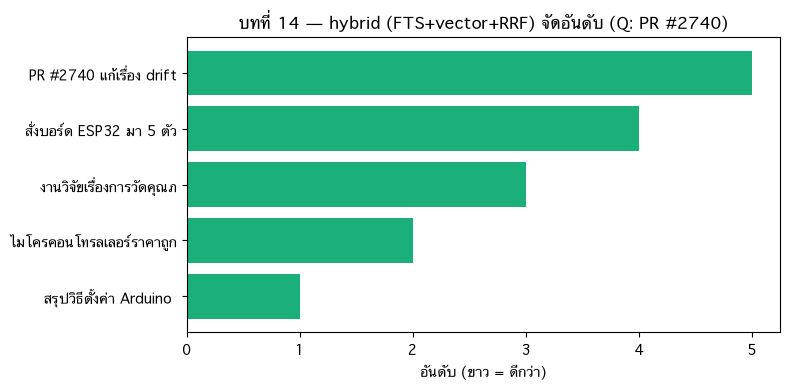

In [7]:
# @@VIZ@@
import matplotlib, matplotlib.pyplot as plt
from matplotlib import font_manager as _fm
_av={f.name for f in _fm.fontManager.ttflist}
for _f in ['Thonburi','Loma','Sarabun','Noto Sans Thai','TH Sarabun New']:
    if _f in _av: matplotlib.rcParams['font.family']=_f; break
matplotlib.rcParams['axes.unicode_minus']=False
q='PR #2740'; r=hybrid(q,k=5)
lb=[t[:24] for t in r['text']]; ranks=list(range(len(lb),0,-1))
plt.figure(figsize=(8,4)); plt.barh(lb[::-1],ranks[::-1],color='#1baf7a')
plt.title(f'บทที่ 14 — hybrid (FTS+vector+RRF) จัดอันดับ (Q: {q})')
plt.xlabel('อันดับ (ยาว = ดีกว่า)'); plt.tight_layout(); plt.show()


**บทต่อไป:** `ch15_lancedb_time_travel.ipynb` — ฟีเจอร์ที่ Chroma ไม่มี: ย้อนเวลา/versioning
